In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from shapely.geometry import Polygon, Point
from shapely.plotting import plot_polygon
from matplotlib.path import Path

In [2]:
path = {
'coords': '/home/vicentev/projects/def-allen/vicentev/analysis-vicente/grid/coordinates_seagrid_SalishSea201702.nc',
'mask': '/home/vicentev/projects/def-allen/vicentev/analysis-vicente/grid/mesh_mask202108_TDV.nc',
'bathy':'/home/vicentev/projects/def-allen/vicentev/analysis-vicente/grid/bathymetry_202108.nc'
}
#
coords = xr.open_dataset(path['coords'], decode_times=False)
mask = xr.open_dataset(path['mask'])
bathy = xr.open_dataset(path['bathy'])

In [3]:
def finder2(target_lat, target_lon,mask=mask):
    lat = mask.nav_lat
    lon = mask.nav_lon
    distance = ((lat - target_lat)**2 + (lon - target_lon)**2)**0.5
    nearest_index = distance.argmin()
    return int(nearest_index // lon.shape[1]), int(nearest_index % lon.shape[1])

In [4]:
Nx1_1, Ny1_1 = [132,170], [665,680]
Nx1_2, Ny1_2 = [170,200], [680,620]
Nx1_3, Ny1_3 = [135,200], [620,620]
#
polygon_coords_N1 = [
    (Nx1_1[0], Ny1_1[0]),
    (Nx1_1[1], Ny1_1[1]),
    (Nx1_2[1], Ny1_2[1]),
    (Nx1_3[1], Ny1_3[1]),
    (Nx1_3[0], Ny1_3[0])
]
polygon_N1 = Polygon(polygon_coords_N1)
#
N1_lon_1, N1_lat_1 = [mask.nav_lon[Ny1_1[0],Nx1_1[0]].values, mask.nav_lon[Ny1_1[1],Nx1_1[1]].values], [mask.nav_lat[Ny1_1[0],Nx1_1[0]].values, mask.nav_lat[Ny1_1[1],Nx1_1[1]].values]
N1_lon_2, N1_lat_2 = [mask.nav_lon[Ny1_2[0],Nx1_2[0]].values, mask.nav_lon[Ny1_2[1],Nx1_2[1]].values], [mask.nav_lat[Ny1_2[0],Nx1_2[0]].values, mask.nav_lat[Ny1_2[1],Nx1_2[1]].values]
N1_lon_3, N1_lat_3 = [mask.nav_lon[Ny1_3[0],Nx1_3[0]].values, mask.nav_lon[Ny1_3[1],Nx1_3[1]].values], [mask.nav_lat[Ny1_3[0],Nx1_3[0]].values, mask.nav_lat[Ny1_3[1],Nx1_3[1]].values]
#
polygon_lon_lat_N1 = [
    (N1_lon_1[0], N1_lat_1[0]),
    (N1_lon_1[1], N1_lat_1[1]),
    (N1_lon_2[1], N1_lat_2[1]),
    (N1_lon_3[1], N1_lat_3[1]),
    (N1_lon_3[0], N1_lat_3[0])
]
polygon_coors_N1 = Polygon(polygon_lon_lat_N1)


In [5]:
Sx1_1, Sy1_1 = [202,292], [505,505]
Sx1_2, Sy1_2 = [300,315], [505,480]
Sx1_3, Sy1_3 = [210,238], [500,465]
Sx1_4, Sy1_4 = [238,245], [465,410]
Sx1_5, Sy1_5 = [302, 280], [410, 470]
Sx1_6, Sy1_6 = [245,302], [410,410]
#
polygon_coords_S1 = [
    (Sx1_1[0], Sy1_1[0]),
    (Sx1_1[1], Sy1_1[1]),
    (Sx1_5[1], Sy1_5[1]),
    (Sx1_4[0], Sy1_4[0])
]
polygon_S1 = Polygon(polygon_coords_S1)
#
S1_lon_1, S1_lat_1 = [mask.nav_lon[Sy1_1[0],Sx1_1[0]].values, mask.nav_lon[Sy1_1[1],Sx1_1[1]].values], [mask.nav_lat[Sy1_1[0],Sx1_1[0]].values, mask.nav_lat[Sy1_1[1],Sx1_1[1]].values]
S1_lon_2, S1_lat_2 = [mask.nav_lon[Sy1_2[0],Sx1_2[0]].values, mask.nav_lon[Sy1_2[1],Sx1_2[1]].values], [mask.nav_lat[Sy1_2[0],Sx1_2[0]].values, mask.nav_lat[Sy1_2[1],Sx1_2[1]].values]
S1_lon_3, S1_lat_3 = [mask.nav_lon[Sy1_3[0],Sx1_3[0]].values, mask.nav_lon[Sy1_3[1],Sx1_3[1]].values], [mask.nav_lat[Sy1_3[0],Sx1_3[0]].values, mask.nav_lat[Sy1_3[1],Sx1_3[1]].values]
S1_lon_4, S1_lat_4 = [mask.nav_lon[Sy1_4[0],Sx1_4[0]].values, mask.nav_lon[Sy1_4[1],Sx1_4[1]].values], [mask.nav_lat[Sy1_4[0],Sx1_4[0]].values, mask.nav_lat[Sy1_4[1],Sx1_4[1]].values]
S1_lon_5, S1_lat_5 = [mask.nav_lon[Sy1_5[0],Sx1_5[0]].values, mask.nav_lon[Sy1_5[1],Sx1_5[1]].values], [mask.nav_lat[Sy1_5[0],Sx1_5[0]].values, mask.nav_lat[Sy1_5[1],Sx1_5[1]].values]
S1_lon_6, S1_lat_6 = [mask.nav_lon[Sy1_6[0],Sx1_6[0]].values, mask.nav_lon[Sy1_6[1],Sx1_6[1]].values], [mask.nav_lat[Sy1_6[0],Sx1_6[0]].values, mask.nav_lat[Sy1_6[1],Sx1_6[1]].values]
#
polygon_lon_lat_S1 = [
    (S1_lon_1[0], S1_lat_1[0]),
    (S1_lon_1[1], S1_lat_1[1]),
    (S1_lon_5[1], S1_lat_5[1]),
    (S1_lon_4[0], S1_lat_4[0])
]
polygon_coors_S1 = Polygon(polygon_lon_lat_S1)

In [6]:
NG = [49.727, -124.68]
S415 = [49.25, -123.667]
y_N1, x_N1 = finder2(NG[0], NG[1])
y_S1, x_S1 = finder2(S415[0], S415[1])

In [7]:
lat_source = 49.195045
lon_source = -123.301956
y_source, x_source = finder2(lat_source, lon_source)

/tmp/ipykernel_2263038/1308823656.py:18: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax[1].pcolormesh(mask['nav_lon'], mask['nav_lat'], mask['tmask'][0][0], cmap = cmap)


/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


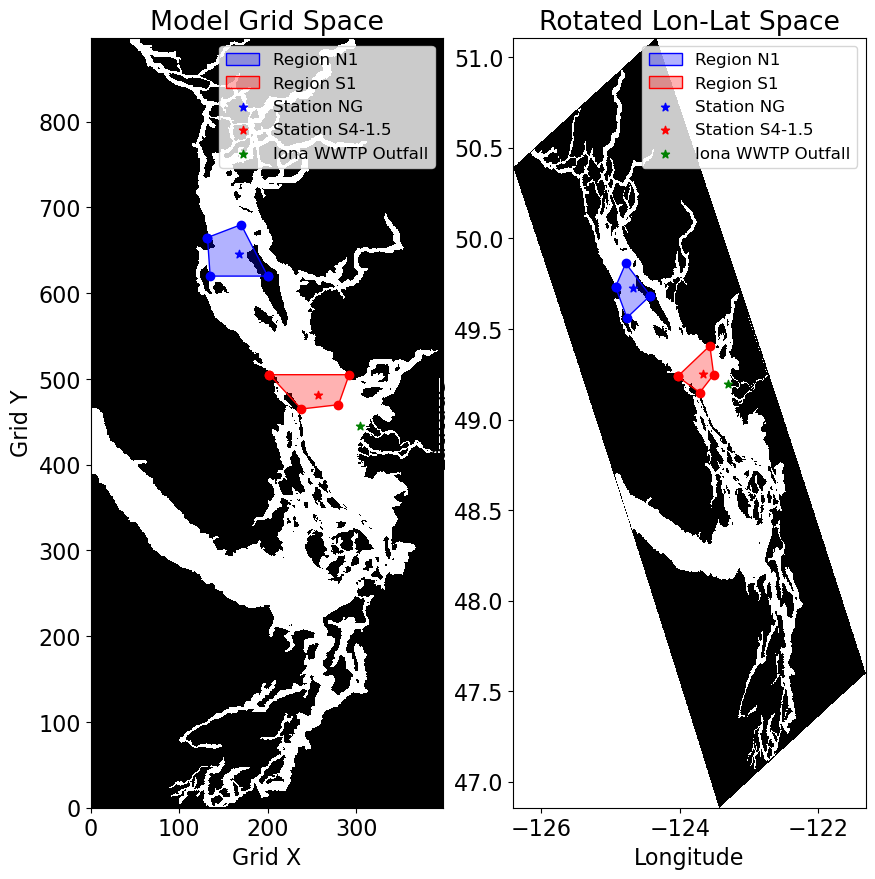

In [8]:
plt.rcParams.update({'font.size': 16})
colors_0 = [(0, 0, 0, 1),  # Black for land
          (0, 0, 0, 0)]  # Transparent for water
cmap = ListedColormap(colors_0)
#
fig, ax = plt.subplots(1,2,figsize = (10,10))
ax[0].pcolormesh(mask['tmask'][0][0], cmap = cmap)
plot_polygon(polygon_N1, ax=ax[0], color = 'b', label = 'Region N1')
plot_polygon(polygon_S1, ax=ax[0], color = 'r', label = 'Region S1')
ax[0].scatter(x_N1, y_N1, marker = '*', c = 'b', label = 'Station NG')
ax[0].scatter(x_S1, y_S1, marker = '*', c = 'r', label = 'Station S4-1.5')
ax[0].scatter(x_source, y_source, marker = '*', c = 'g', label = 'Iona WWTP Outfall')
ax[0].set_title('Model Grid Space')
ax[0].set_xlabel('Grid X')
ax[0].set_ylabel('Grid Y')
ax[0].legend(fontsize = 12)
#
ax[1].pcolormesh(mask['nav_lon'], mask['nav_lat'], mask['tmask'][0][0], cmap = cmap)
plot_polygon(polygon_coors_N1, ax=ax[1], color = 'b', label = 'Region N1')
plot_polygon(polygon_coors_S1, ax=ax[1], color = 'r', label = 'Region S1')
ax[1].scatter(NG[1], NG[0], marker = '*', c = 'b', label = 'Station NG')
ax[1].scatter(S415[1], S415[0], marker = '*', c = 'r', label = 'Station S4-1.5')
ax[1].scatter(lon_source, lat_source, marker = '*', c = 'g', label = 'Iona WWTP Outfall')
ax[1].set_title('Rotated Lon-Lat Space')
ax[1].set_xlabel('Longitude')
ax[1].set_ylabel('Latitude')
ax[1].legend(fontsize = 12)


Functions

In [9]:
def volume_region_50m_bottom(polygon):
    mesh = xr.open_dataset(path['mask'])
    volume = mesh['volume']
    mask = xr.open_dataset(path['mask'])['tmask'][0]
    #
    depths = mesh['gdept_1d'][0] 
    depth_condition = depths >= 50
    # 
    depth_mask_3d = depth_condition.values[:, np.newaxis, np.newaxis]
    #    
    x = volume['x']  
    y = volume['y'] 
    #
    xx, yy = np.meshgrid(x, y)
    #
    # 2D Polygon Mask
    polygon_mask_2d = np.array([
        [polygon.contains(Point(xx[j, i], yy[j, i])) for i in range(len(x))]
        for j in range(len(y))
    ])

    # to 3D
    nz = volume.sizes['z']
    polygon_mask_3d = np.repeat(polygon_mask_2d[np.newaxis, :, :], nz, axis=0)

    # inside polygon  + in water + > 50 m
    combined_mask = (polygon_mask_3d & (mask.values == 1) & depth_mask_3d)

    # Applying mask
    mask_da = xr.DataArray(combined_mask, dims=volume.dims, coords=volume.coords)
    volume_in_polygon_water = volume.where(mask_da).sum().item()
    
    return volume_in_polygon_water

In [10]:
volume_N1 = volume_region_50m_bottom(polygon_N1)
volume_S1 = volume_region_50m_bottom(polygon_S1)
print(volume_N1/1e9, 'km^3')
print(volume_S1/1e9, 'km^3')

64.30395579 km^3
109.140915985 km^3


In [11]:
def polygon_definition_data_colloidal(ds, region_polygon,  depth_min=50):
#
    lons = ds['lon'].values
    lats = ds['lat'].values
    depths = ds['z'].values
    statuses = ds['status'].values
    #
    points_flat = np.column_stack((lons.ravel(), lats.ravel()))
    poly_path = Path(region_polygon)
    # points inside polygon
    inside_mask_flat = poly_path.contains_points(points_flat)
    inside_mask = inside_mask_flat.reshape(lons.shape)
    # >= 50 mask
    deep_mask = depths >= depth_min
    #deep_mask = depths >= depth_min
    # Colloidal status 
    status_mask = np.isin(statuses, 2) 
    #
    valid_mask = inside_mask & deep_mask & status_mask
    #
    counts = np.sum(valid_mask, axis=0) 
    #
    times = ds['time'].values
    time_index = np.nanmax(times, axis=0) 
    #
    return pd.DataFrame({'count': counts}, index=time_index)

In [12]:
def particles_amount(
    lons, lats, mask=mask, num_lon=200, num_lat=200
):
    nav_lon = mask['nav_lon'].values
    nav_lat = mask['nav_lat'].values

    lon_edges = np.linspace(nav_lon.min(), nav_lon.max(), num_lon + 1)
    lat_edges = np.linspace(nav_lat.min(), nav_lat.max(), num_lat + 1)

    lon_centers = (lon_edges[:-1] + lon_edges[1:]) / 2
    lat_centers = (lat_edges[:-1] + lat_edges[1:]) / 2

    counts, xedges, yedges = np.histogram2d(
        lons, lats,
        bins=[lon_edges, lat_edges]
    )

    df = pd.DataFrame(
        counts.T,  
        index=lat_centers,
        columns=lon_centers
    )

    Xcenters, Ycenters = np.meshgrid(lon_centers, lat_centers)

    flat_lon = Xcenters.ravel()
    flat_lat = Ycenters.ravel()

    ii_sed = np.zeros(flat_lon.size, dtype=int)
    jj_sed = np.zeros(flat_lon.size, dtype=int)

    for k in range(flat_lon.size):
        jj, ii = finder2(flat_lat[k], flat_lon[k], mask)
        ii_sed[k] = ii
        jj_sed[k] = jj

    ii_sed = ii_sed.reshape(Xcenters.shape)
    jj_sed = jj_sed.reshape(Ycenters.shape)

    grid_indices = (ii_sed, jj_sed)

    raw_hist = (counts, xedges, yedges)

    return df, raw_hist, grid_indices


# Test Ads. = 0.05, MC = 0.2 and Vel. C = N

Bed Shear Stress: 0.001 Pa and 0.0075 Pa

In [13]:
B_Shear_T1 = ['/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112007_run_365_days_MC_0_2_Tau_0_001_Ads_0_05_Vel_N.nc', 
              '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112007_run_365_days_ADS_0_05_TAU_0_0075_MC_0_2.nc']
data_T1, data_T2 = xr.open_dataset(B_Shear_T1[0]),  xr.open_dataset(B_Shear_T1[1])

In [14]:
counts_S1_T1 = polygon_definition_data_colloidal(data_T1.isel(obs=slice(1092,1215)), polygon_lon_lat_S1)
counts_N1_T1 = polygon_definition_data_colloidal(data_T1.isel(obs=slice(1092,1215)), polygon_lon_lat_N1)
concentration_S1_T1 = np.sum(counts_S1_T1) / volume_S1 / len(data_T1.isel(obs=slice(1092,1215))['obs'])
concentration_N1_T1 = np.sum(counts_N1_T1) / volume_N1 / len(data_T1.isel(obs=slice(1092,1215))['obs'])
ratio_S1_N1_T1 = concentration_S1_T1 / concentration_N1_T1
#
counts_S1_T2 = polygon_definition_data_colloidal(data_T2.isel(obs=slice(1092,1215)), polygon_lon_lat_S1)
counts_N1_T2 = polygon_definition_data_colloidal(data_T2.isel(obs=slice(1092,1215)), polygon_lon_lat_N1)
concentration_S1_T2 = np.sum(counts_S1_T2) / volume_S1 / len(data_T2.isel(obs=slice(1092,1215))['obs'])
concentration_N1_T2 = np.sum(counts_N1_T2) / volume_N1 / len(data_T2.isel(obs=slice(1092,1215))['obs'])
ratio_S1_N1_T2 = concentration_S1_T2 / concentration_N1_T2

/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [15]:
wc_T1 = data_T1.isel(obs=slice(1092,1215)).where(data_T1.isel(obs=slice(1092,1215))['status'] == 2)
wc_T2 = data_T2.isel(obs=slice(1092,1215)).where(data_T2.isel(obs=slice(1092,1215))['status'] == 2)
#
amount_T1, _, grid_ijT1 = particles_amount(wc_T1['lon'].values.flatten(), wc_T1['lat'].values.flatten())
amount_T2, _, grid_ijT2 = particles_amount(wc_T2['lon'].values.flatten(), wc_T2['lat'].values.flatten())

/tmp/ipykernel_2263038/3699566202.py:6: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  t1_plot = ax[0].pcolormesh(grid_ijT1[0], grid_ijT1[1], amount_T1,
/tmp/ipykernel_2263038/3699566202.py:23: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  t2_plot = ax[1].pcolormesh(grid_ijT2[0], grid_ijT2[1], amount_T2,


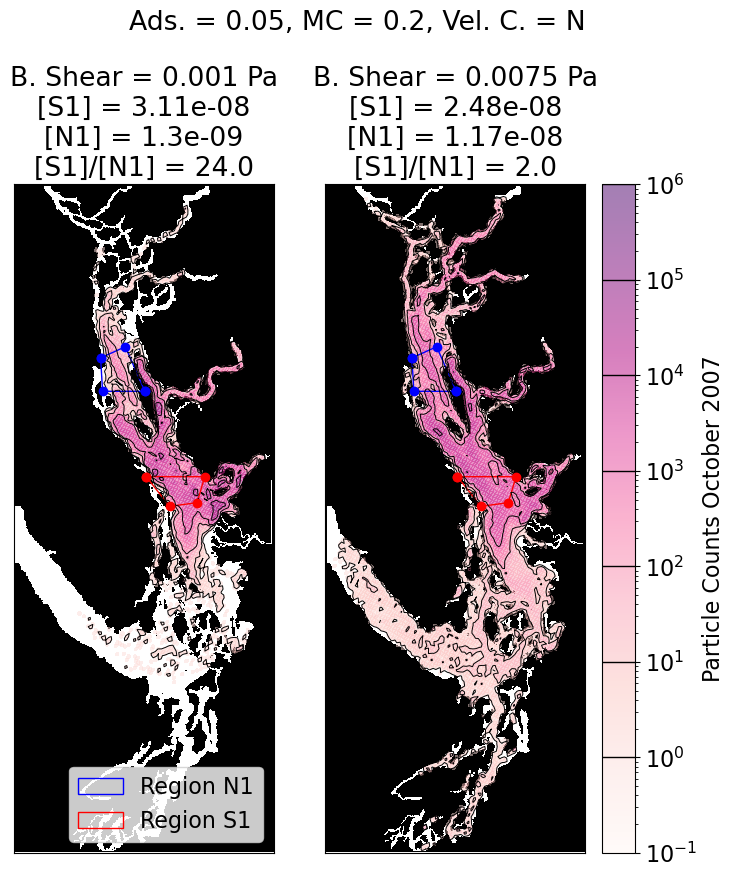

In [16]:
levels = [1, 10e0, 10e1, 10e2, 10e3, 10e4, 10e5]
#
fig, ax = plt.subplots(1,2, figsize = (8,9))
ax[0].pcolormesh(mask['tmask'][0][0], cmap = cmap)
#ax[0].contour(bathy['Bathymetry'], cmap = 'Greys')
t1_plot = ax[0].pcolormesh(grid_ijT1[0], grid_ijT1[1], amount_T1,
                 norm=colors.LogNorm(vmin=amount_T1.min().min() + 1e-1, vmax=10e5), 
                 cmap = 'RdPu', alpha = .5)
#
ax[0].contour(grid_ijT1[0], grid_ijT1[1], amount_T1, colors='black', levels = levels
              ,linewidths=0.7, linestyles='solid')
#
plot_polygon(polygon_N1, ax=ax[0], color = 'b', label = 'Region N1', fill=False)
plot_polygon(polygon_S1, ax=ax[0], color = 'r', label = 'Region S1', fill=False)
#
ax[0].set_title('B. Shear = 0.001 Pa' + '\n' +
                rf'[S1] = {np.round(concentration_S1_T1.values[0],10)}' + '\n' 
                + rf'[N1] = {np.round(concentration_N1_T1.values[0], 10)}' + '\n' 
                + rf'[S1]/[N1] = {np.round(ratio_S1_N1_T1.values[0])}' )
#
ax[1].pcolormesh(mask['tmask'][0][0], cmap = cmap)
#ax[1].contour(bathy['Bathymetry'], cmap = 'Greys')
t2_plot = ax[1].pcolormesh(grid_ijT2[0], grid_ijT2[1], amount_T2,
                 norm=colors.LogNorm(vmin=amount_T2.min().min() + 1e-1, vmax=10e5), 
                 cmap = 'RdPu', alpha = .5)
#
ax[1].contour(grid_ijT2[0], grid_ijT2[1], amount_T2, colors='black', levels = levels
              ,linewidths=0.7, linestyles='solid')
#
plot_polygon(polygon_N1, ax=ax[1], color = 'b', label = 'Region N1', fill=False)
plot_polygon(polygon_S1, ax=ax[1], color = 'r', label = 'Region S1', fill=False)
#
ax[1].set_title('B. Shear = 0.0075 Pa' + '\n' +
                rf'[S1] = {np.round(concentration_S1_T2.values[0],10)}' + '\n' 
                + rf'[N1] = {np.round(concentration_N1_T2.values[0], 10)}' + '\n' 
                + rf'[S1]/[N1] = {np.round(ratio_S1_N1_T2.values[0])}' )
#
#cbar_t1 = plt.colorbar(t1_plot, ax = ax[0])
cbar_t2 = plt.colorbar(t2_plot, ax = ax[1])
cbar_t2.set_label('Particle Counts October 2007')
for lev in levels:
    cbar_t2.ax.hlines(
        lev, 
        *cbar_t2.ax.get_xlim(),   # span full width
        colors='black',
        linewidth=1
    )
#
for axis in ax:
    axis.set_aspect(1.14)
    axis.set_xticks([])
    axis.set_yticks([])
ax[0].legend(loc = 'lower right')    
#
plt.suptitle('Ads. = 0.05, MC = 0.2, Vel. C. = N')
plt.tight_layout()

# Test Ads. = 0.01, MC = 0.2 and Vel. C = Hx1.2

Bed Shear Stress: 0.0025 Pa and 0.005 Pa

In [17]:
B_Shear_T2 = ['/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112007_run_365_days_MC_0_2_Tau_0_0025_Ads_0_01_Vel_Hx1_2.nc', 
              '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112007_run_365_days_MC_0_2_Tau_0_005_Ads_0_01_Vel_Hx1_2.nc']
data_T3, data_T4 = xr.open_dataset(B_Shear_T2[0]),  xr.open_dataset(B_Shear_T2[1])

In [18]:
counts_S1_T3 = polygon_definition_data_colloidal(data_T3.isel(obs=slice(1092,1215)), polygon_lon_lat_S1)
counts_N1_T3 = polygon_definition_data_colloidal(data_T3.isel(obs=slice(1092,1215)), polygon_lon_lat_N1)
concentration_S1_T3 = np.sum(counts_S1_T3) / volume_S1 / len(data_T3.isel(obs=slice(1092,1215))['obs'])
concentration_N1_T3 = np.sum(counts_N1_T3) / volume_N1 / len(data_T3.isel(obs=slice(1092,1215))['obs'])
ratio_S1_N1_T3 = concentration_S1_T3 / concentration_N1_T3
#
counts_S1_T4 = polygon_definition_data_colloidal(data_T4.isel(obs=slice(1092,1215)), polygon_lon_lat_S1)
counts_N1_T4 = polygon_definition_data_colloidal(data_T4.isel(obs=slice(1092,1215)), polygon_lon_lat_N1)
concentration_S1_T4 = np.sum(counts_S1_T4) / volume_S1 / len(data_T4.isel(obs=slice(1092,1215))['obs'])
concentration_N1_T4 = np.sum(counts_N1_T4) / volume_N1 / len(data_T4.isel(obs=slice(1092,1215))['obs'])
ratio_S1_N1_T4 = concentration_S1_T4 / concentration_N1_T4

/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [19]:
wc_T3 = data_T3.isel(obs=slice(1092,1215)).where(data_T3.isel(obs=slice(1092,1215))['status'] == 2)
wc_T4 = data_T4.isel(obs=slice(1092,1215)).where(data_T4.isel(obs=slice(1092,1215))['status'] == 2)
#
amount_T3, _, grid_ijT3 = particles_amount(wc_T3['lon'].values.flatten(), wc_T3['lat'].values.flatten())
amount_T4, _, grid_ijT4 = particles_amount(wc_T4['lon'].values.flatten(), wc_T4['lat'].values.flatten())

/tmp/ipykernel_2263038/797507724.py:6: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  t3_plot = ax[0].pcolormesh(grid_ijT3[0], grid_ijT3[1], amount_T3,
/tmp/ipykernel_2263038/797507724.py:23: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  t4_plot = ax[1].pcolormesh(grid_ijT4[0], grid_ijT4[1], amount_T4,


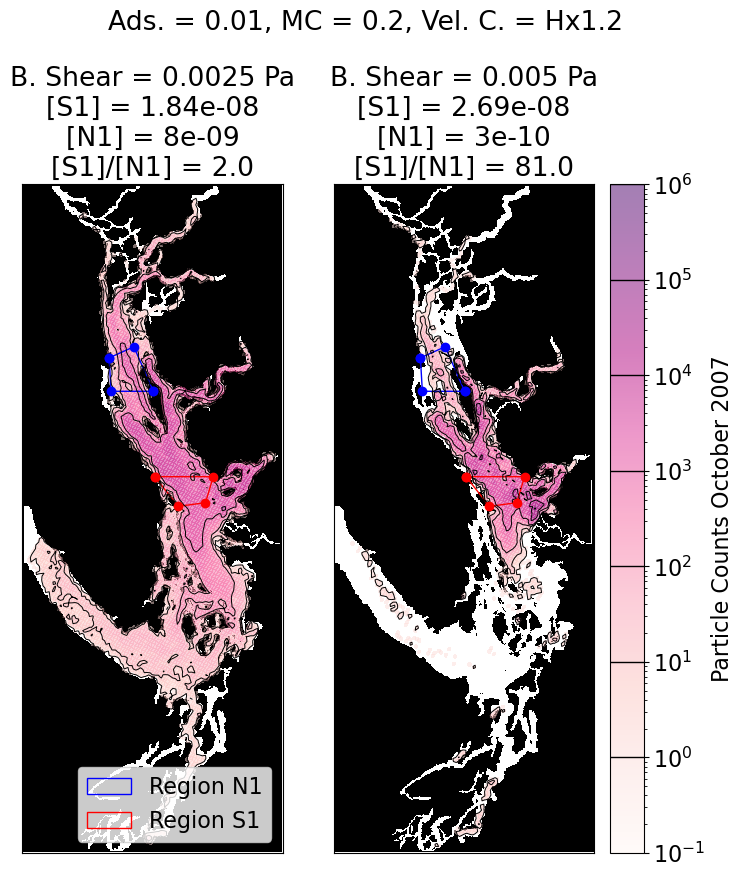

In [20]:
levels = [1, 10e0, 10e1, 10e2, 10e3, 10e4, 10e5]
#
fig, ax = plt.subplots(1,2, figsize = (8,9))
ax[0].pcolormesh(mask['tmask'][0][0], cmap = cmap)
#ax[0].contour(bathy['Bathymetry'], cmap = 'Greys')
t3_plot = ax[0].pcolormesh(grid_ijT3[0], grid_ijT3[1], amount_T3,
                 norm=colors.LogNorm(vmin=amount_T3.min().min() + 1e-1, vmax=10e5), 
                 cmap = 'RdPu', alpha = .5)
#
ax[0].contour(grid_ijT3[0], grid_ijT3[1], amount_T3, colors='black', levels = levels
              ,linewidths=0.7, linestyles='solid')
#
plot_polygon(polygon_N1, ax=ax[0], color = 'b', label = 'Region N1', fill=False)
plot_polygon(polygon_S1, ax=ax[0], color = 'r', label = 'Region S1', fill=False)
#
ax[0].set_title('B. Shear = 0.0025 Pa' + '\n' +
                rf'[S1] = {np.round(concentration_S1_T3.values[0],10)}' + '\n' 
                + rf'[N1] = {np.round(concentration_N1_T3.values[0], 10)}' + '\n' 
                + rf'[S1]/[N1] = {np.round(ratio_S1_N1_T3.values[0])}' )
#
ax[1].pcolormesh(mask['tmask'][0][0], cmap = cmap)
#ax[1].contour(bathy['Bathymetry'], cmap = 'Greys')
t4_plot = ax[1].pcolormesh(grid_ijT4[0], grid_ijT4[1], amount_T4,
                 norm=colors.LogNorm(vmin=amount_T3.min().min() + 1e-1, vmax=10e5), 
                 cmap = 'RdPu', alpha = .5)
#
ax[1].contour(grid_ijT4[0], grid_ijT4[1], amount_T4, colors='black', levels = levels
              ,linewidths=0.7, linestyles='solid')
#
plot_polygon(polygon_N1, ax=ax[1], color = 'b', label = 'Region N1', fill=False)
plot_polygon(polygon_S1, ax=ax[1], color = 'r', label = 'Region S1', fill=False)
#
ax[1].set_title('B. Shear = 0.005 Pa' + '\n' +
                rf'[S1] = {np.round(concentration_S1_T4.values[0],10)}' + '\n' 
                + rf'[N1] = {np.round(concentration_N1_T4.values[0], 10)}' + '\n' 
                + rf'[S1]/[N1] = {np.round(ratio_S1_N1_T4.values[0])}' )
#
#cbar_t1 = plt.colorbar(t1_plot, ax = ax[0])
cbar_t4 = plt.colorbar(t4_plot, ax = ax[1])
cbar_t4.set_label('Particle Counts October 2007')
for lev in levels:
    cbar_t4.ax.hlines(
        lev, 
        *cbar_t4.ax.get_xlim(),   # span full width
        colors='black',
        linewidth=1
    )
#
for axis in ax:
    axis.set_aspect(1.14)
    axis.set_xticks([])
    axis.set_yticks([])
ax[0].legend(loc = 'lower right')    
#
plt.suptitle('Ads. = 0.01, MC = 0.2, Vel. C. = Hx1.2')
plt.tight_layout()

# Test Ads. = 0.1, MC = 0.2 and Vel. C = N

Bed Shear Stress: 0.0025 Pa, 0.005 Pa and 0.012 Pa

In [21]:
B_Shear_T3 = ['/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112007_run_365_days_MC_0_2_Tau_0_0025_Ads_0_1_Vel_N.nc', 
              '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112007_run_365_days_MC_0_2_Tau_0_005_Ads_0_1_Vel_N.nc', 
              '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112007_run_365_days_MC_0_2_Tau_0_012_Ads_0_1_Vel_N.nc']
data_T5, data_T6, data_T7 = xr.open_dataset(B_Shear_T3[0]),  xr.open_dataset(B_Shear_T3[1]),  xr.open_dataset(B_Shear_T3[2])

In [22]:
counts_S1_T5 = polygon_definition_data_colloidal(data_T5.isel(obs=slice(1092,1215)), polygon_lon_lat_S1)
counts_N1_T5 = polygon_definition_data_colloidal(data_T5.isel(obs=slice(1092,1215)), polygon_lon_lat_N1)
concentration_S1_T5 = np.sum(counts_S1_T5) / volume_S1 / len(data_T5.isel(obs=slice(1092,1215))['obs'])
concentration_N1_T5 = np.sum(counts_N1_T5) / volume_N1 / len(data_T5.isel(obs=slice(1092,1215))['obs'])
ratio_S1_N1_T5 = concentration_S1_T5 / concentration_N1_T5
#
counts_S1_T6 = polygon_definition_data_colloidal(data_T6.isel(obs=slice(1092,1215)), polygon_lon_lat_S1)
counts_N1_T6 = polygon_definition_data_colloidal(data_T6.isel(obs=slice(1092,1215)), polygon_lon_lat_N1)
concentration_S1_T6 = np.sum(counts_S1_T6) / volume_S1 / len(data_T6.isel(obs=slice(1092,1215))['obs'])
concentration_N1_T6 = np.sum(counts_N1_T6) / volume_N1 / len(data_T6.isel(obs=slice(1092,1215))['obs'])
ratio_S1_N1_T6 = concentration_S1_T6 / concentration_N1_T6
#

counts_S1_T7 = polygon_definition_data_colloidal(data_T7.isel(obs=slice(1092,1215)), polygon_lon_lat_S1)
counts_N1_T7 = polygon_definition_data_colloidal(data_T7.isel(obs=slice(1092,1215)), polygon_lon_lat_N1)
concentration_S1_T7 = np.sum(counts_S1_T7) / volume_S1 / len(data_T7.isel(obs=slice(1092,1215))['obs'])
concentration_N1_T7 = np.sum(counts_N1_T7) / volume_N1 / len(data_T7.isel(obs=slice(1092,1215))['obs'])
ratio_S1_N1_T7 = concentration_S1_T7 / concentration_N1_T7

/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or 

In [23]:
wc_T5 = data_T5.isel(obs=slice(1092,1215)).where(data_T5.isel(obs=slice(1092,1215))['status'] == 2)
wc_T6 = data_T6.isel(obs=slice(1092,1215)).where(data_T6.isel(obs=slice(1092,1215))['status'] == 2)
wc_T7 = data_T7.isel(obs=slice(1092,1215)).where(data_T7.isel(obs=slice(1092,1215))['status'] == 2)
#
amount_T5, _, grid_ijT5 = particles_amount(wc_T5['lon'].values.flatten(), wc_T5['lat'].values.flatten())
amount_T6, _, grid_ijT6 = particles_amount(wc_T6['lon'].values.flatten(), wc_T6['lat'].values.flatten())
amount_T7, _, grid_ijT7 = particles_amount(wc_T7['lon'].values.flatten(), wc_T7['lat'].values.flatten())

/tmp/ipykernel_2263038/554763627.py:6: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  t5_plot = ax[0].pcolormesh(grid_ijT5[0], grid_ijT5[1], amount_T5,
/tmp/ipykernel_2263038/554763627.py:23: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  t6_plot = ax[1].pcolormesh(grid_ijT6[0], grid_ijT6[1], amount_T6,
/tmp/ipykernel_2263038/554763627.py:40: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolorm

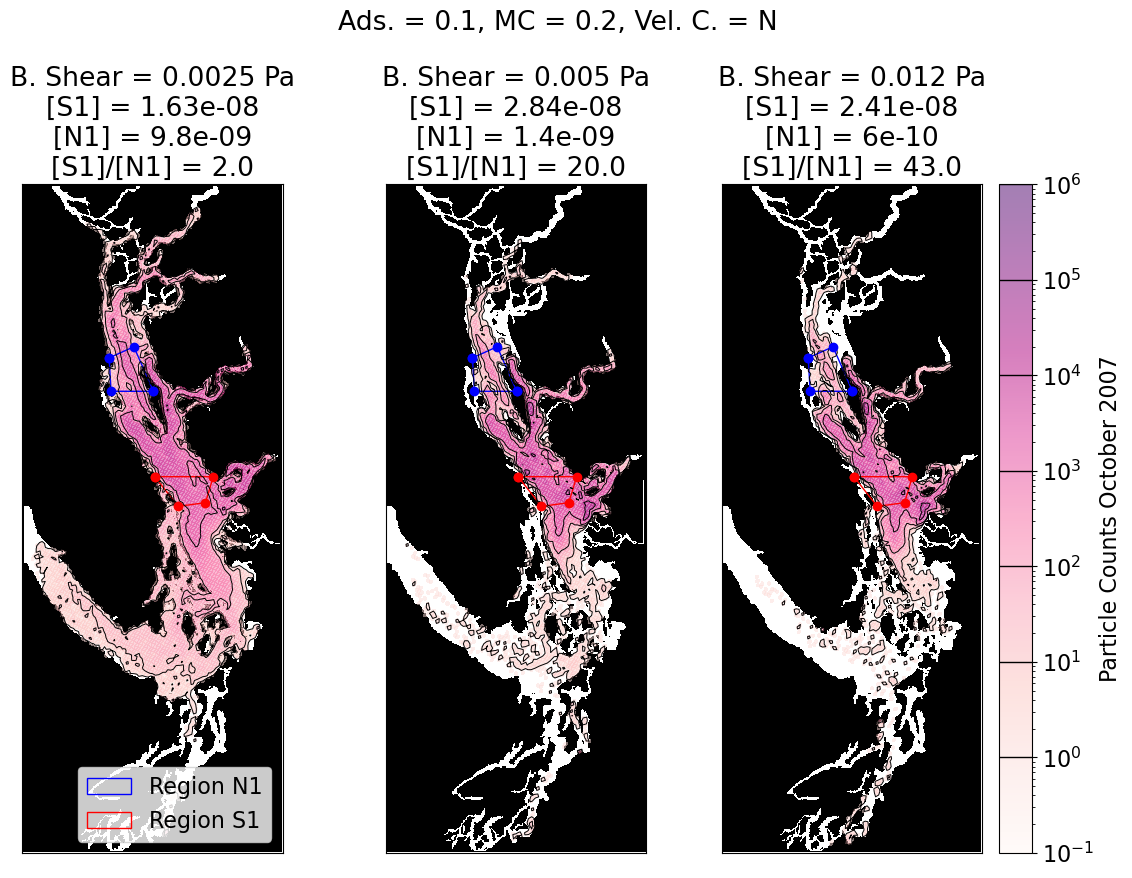

In [24]:
levels = [1, 10e0, 10e1, 10e2, 10e3, 10e4, 10e5]
#
fig, ax = plt.subplots(1,3, figsize = (12,9))
ax[0].pcolormesh(mask['tmask'][0][0], cmap = cmap)
#ax[0].contour(bathy['Bathymetry'], cmap = 'Greys')
t5_plot = ax[0].pcolormesh(grid_ijT5[0], grid_ijT5[1], amount_T5,
                 norm=colors.LogNorm(vmin=amount_T5.min().min() + 1e-1, vmax=10e5), 
                 cmap = 'RdPu', alpha = .5)
#
ax[0].contour(grid_ijT5[0], grid_ijT5[1], amount_T5, colors='black', levels = levels
              ,linewidths=0.7, linestyles='solid')
#
plot_polygon(polygon_N1, ax=ax[0], color = 'b', label = 'Region N1', fill=False)
plot_polygon(polygon_S1, ax=ax[0], color = 'r', label = 'Region S1', fill=False)
#
ax[0].set_title('B. Shear = 0.0025 Pa' + '\n' +
                rf'[S1] = {np.round(concentration_S1_T5.values[0],10)}' + '\n' 
                + rf'[N1] = {np.round(concentration_N1_T5.values[0], 10)}' + '\n' 
                + rf'[S1]/[N1] = {np.round(ratio_S1_N1_T5.values[0])}' )
#
ax[1].pcolormesh(mask['tmask'][0][0], cmap = cmap)
#ax[1].contour(bathy['Bathymetry'], cmap = 'Greys')
t6_plot = ax[1].pcolormesh(grid_ijT6[0], grid_ijT6[1], amount_T6,
                 norm=colors.LogNorm(vmin=amount_T6.min().min() + 1e-1, vmax=10e5), 
                 cmap = 'RdPu', alpha = .5)
#
ax[1].contour(grid_ijT6[0], grid_ijT6[1], amount_T6, colors='black', levels = levels
              ,linewidths=0.7, linestyles='solid')
#
plot_polygon(polygon_N1, ax=ax[1], color = 'b', label = 'Region N1', fill=False)
plot_polygon(polygon_S1, ax=ax[1], color = 'r', label = 'Region S1', fill=False)
#
ax[1].set_title('B. Shear = 0.005 Pa' + '\n' +
                rf'[S1] = {np.round(concentration_S1_T6.values[0],10)}' + '\n' 
                + rf'[N1] = {np.round(concentration_N1_T6.values[0], 10)}' + '\n' 
                + rf'[S1]/[N1] = {np.round(ratio_S1_N1_T6.values[0])}' )
#
ax[2].pcolormesh(mask['tmask'][0][0], cmap = cmap)
#ax[1].contour(bathy['Bathymetry'], cmap = 'Greys')
t7_plot = ax[2].pcolormesh(grid_ijT7[0], grid_ijT7[1], amount_T7,
                 norm=colors.LogNorm(vmin=amount_T7.min().min() + 1e-1, vmax=10e5), 
                 cmap = 'RdPu', alpha = .5)
#
ax[2].contour(grid_ijT7[0], grid_ijT7[1], amount_T7, colors='black', levels = levels
              ,linewidths=0.7, linestyles='solid')
#
plot_polygon(polygon_N1, ax=ax[2], color = 'b', label = 'Region N1', fill=False)
plot_polygon(polygon_S1, ax=ax[2], color = 'r', label = 'Region S1', fill=False)
#
ax[2].set_title('B. Shear = 0.012 Pa' + '\n' +
                rf'[S1] = {np.round(concentration_S1_T7.values[0],10)}' + '\n' 
                + rf'[N1] = {np.round(concentration_N1_T7.values[0], 10)}' + '\n' 
                + rf'[S1]/[N1] = {np.round(ratio_S1_N1_T7.values[0])}' )
#


#cbar_t1 = plt.colorbar(t1_plot, ax = ax[0])
cbar_t7 = plt.colorbar(t7_plot, ax = ax[2])
cbar_t7.set_label('Particle Counts October 2007')
for lev in levels:
    cbar_t7.ax.hlines(
        lev, 
        *cbar_t7.ax.get_xlim(),   # span full width
        colors='black',
        linewidth=1
    )
#
for axis in ax:
    axis.set_aspect(1.14)
    axis.set_xticks([])
    axis.set_yticks([])
ax[0].legend(loc = 'lower right')    
#
plt.suptitle('Ads. = 0.1, MC = 0.2, Vel. C. = N')
plt.tight_layout()

# Test Ads. = 0.05, MC = 0.2 and Vel. C = Hx1.5

Bed Shear Stress: 0.005 Pa and 0.0075 Pa

In [25]:
B_Shear_T4 = ['/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112007_run_365_days_MC_0_2_Tau_0_005_Ads_0_05_Vel_Hx1_5.nc', 
              '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112007_run_365_days_ADS_0_05_TAU_0_0075_MC_0_2_VEL_Hx1_5.nc']
data_T8, data_T9 = xr.open_dataset(B_Shear_T4[0]),  xr.open_dataset(B_Shear_T4[1])

In [26]:
counts_S1_T8 = polygon_definition_data_colloidal(data_T8.isel(obs=slice(1092,1215)), polygon_lon_lat_S1)
counts_N1_T8 = polygon_definition_data_colloidal(data_T8.isel(obs=slice(1092,1215)), polygon_lon_lat_N1)
concentration_S1_T8 = np.sum(counts_S1_T8) / volume_S1 / len(data_T8.isel(obs=slice(1092,1215))['obs'])
concentration_N1_T8 = np.sum(counts_N1_T8) / volume_N1 / len(data_T8.isel(obs=slice(1092,1215))['obs'])
ratio_S1_N1_T8 = concentration_S1_T8 / concentration_N1_T8
#
counts_S1_T9 = polygon_definition_data_colloidal(data_T9.isel(obs=slice(1092,1215)), polygon_lon_lat_S1)
counts_N1_T9 = polygon_definition_data_colloidal(data_T9.isel(obs=slice(1092,1215)), polygon_lon_lat_N1)
concentration_S1_T9 = np.sum(counts_S1_T9) / volume_S1 / len(data_T9.isel(obs=slice(1092,1215))['obs'])
concentration_N1_T9 = np.sum(counts_N1_T9) / volume_N1 / len(data_T9.isel(obs=slice(1092,1215))['obs'])
ratio_S1_N1_T9 = concentration_S1_T9 / concentration_N1_T9

/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [27]:
wc_T8 = data_T8.isel(obs=slice(1092,1215)).where(data_T8.isel(obs=slice(1092,1215))['status'] == 2)
wc_T9 = data_T9.isel(obs=slice(1092,1215)).where(data_T9.isel(obs=slice(1092,1215))['status'] == 2)
#
amount_T8, _, grid_ijT8 = particles_amount(wc_T8['lon'].values.flatten(), wc_T8['lat'].values.flatten())
amount_T9, _, grid_ijT9 = particles_amount(wc_T9['lon'].values.flatten(), wc_T9['lat'].values.flatten())

/tmp/ipykernel_2263038/3126891510.py:6: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  t8_plot = ax[0].pcolormesh(grid_ijT8[0], grid_ijT8[1], amount_T8,
/tmp/ipykernel_2263038/3126891510.py:23: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  t9_plot = ax[1].pcolormesh(grid_ijT9[0], grid_ijT9[1], amount_T9,


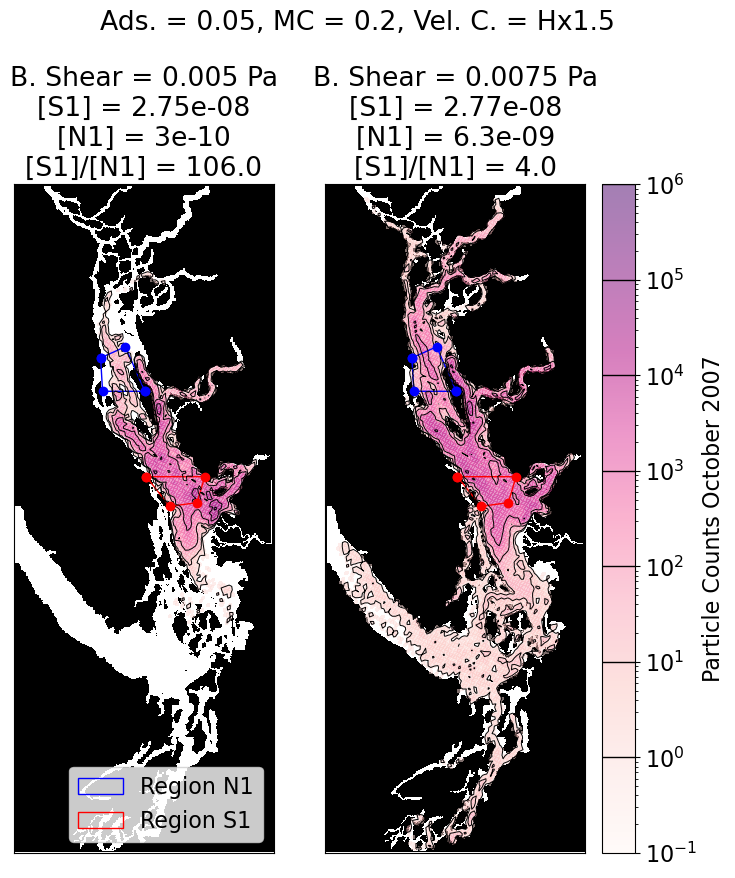

In [28]:
levels = [1, 10e0, 10e1, 10e2, 10e3, 10e4, 10e5]
#
fig, ax = plt.subplots(1,2, figsize = (8,9))
ax[0].pcolormesh(mask['tmask'][0][0], cmap = cmap)
#ax[0].contour(bathy['Bathymetry'], cmap = 'Greys')
t8_plot = ax[0].pcolormesh(grid_ijT8[0], grid_ijT8[1], amount_T8,
                 norm=colors.LogNorm(vmin=amount_T8.min().min() + 1e-1, vmax=10e5), 
                 cmap = 'RdPu', alpha = .5)
#
ax[0].contour(grid_ijT8[0], grid_ijT8[1], amount_T8, colors='black', levels = levels
              ,linewidths=0.7, linestyles='solid')
#
plot_polygon(polygon_N1, ax=ax[0], color = 'b', label = 'Region N1', fill=False)
plot_polygon(polygon_S1, ax=ax[0], color = 'r', label = 'Region S1', fill=False)
#
ax[0].set_title('B. Shear = 0.005 Pa' + '\n' +
                rf'[S1] = {np.round(concentration_S1_T8.values[0],10)}' + '\n' 
                + rf'[N1] = {np.round(concentration_N1_T8.values[0], 10)}' + '\n' 
                + rf'[S1]/[N1] = {np.round(ratio_S1_N1_T8.values[0])}' )
#
ax[1].pcolormesh(mask['tmask'][0][0], cmap = cmap)
#ax[1].contour(bathy['Bathymetry'], cmap = 'Greys')
t9_plot = ax[1].pcolormesh(grid_ijT9[0], grid_ijT9[1], amount_T9,
                 norm=colors.LogNorm(vmin=amount_T8.min().min() + 1e-1, vmax=10e5), 
                 cmap = 'RdPu', alpha = .5)
#
ax[1].contour(grid_ijT9[0], grid_ijT9[1], amount_T9, colors='black', levels = levels
              ,linewidths=0.7, linestyles='solid')
#
plot_polygon(polygon_N1, ax=ax[1], color = 'b', label = 'Region N1', fill=False)
plot_polygon(polygon_S1, ax=ax[1], color = 'r', label = 'Region S1', fill=False)
#
ax[1].set_title('B. Shear = 0.0075 Pa' + '\n' +
                rf'[S1] = {np.round(concentration_S1_T9.values[0],10)}' + '\n' 
                + rf'[N1] = {np.round(concentration_N1_T9.values[0], 10)}' + '\n' 
                + rf'[S1]/[N1] = {np.round(ratio_S1_N1_T9.values[0])}' )
#
#cbar_t1 = plt.colorbar(t1_plot, ax = ax[0])
cbar_t9 = plt.colorbar(t9_plot, ax = ax[1])
cbar_t9.set_label('Particle Counts October 2007')
for lev in levels:
    cbar_t9.ax.hlines(
        lev, 
        *cbar_t9.ax.get_xlim(),   # span full width
        colors='black',
        linewidth=1
    )
#
for axis in ax:
    axis.set_aspect(1.14)
    axis.set_xticks([])
    axis.set_yticks([])
ax[0].legend(loc = 'lower right')    
#
plt.suptitle('Ads. = 0.05, MC = 0.2, Vel. C. = Hx1.5')
plt.tight_layout()